## Objective:

To visually map the physical transformation of our asset universe. We must render a 2D cross-section of our high-dimensional data to prove that our mathematical centering stripped the ocean current, and that our extracted Eigenvectors physically align with the axes of maximum variance.

**The Physics Analogy: The Flashlight in the Cage**

Our data exists in 5-dimensional space ($N=5$). Humans cannot visualize 5D space. We must point a mathematical flashlight at the steel cage and project a 2-dimensional shadow against the wall (e.g., graphing only Asset 0 vs. Asset 1). We will plot the raw data, center it directly on the origin ($0,0$), and overlay the primary eigenvectors to visually verify they act as the structural spine of the market movement.

**Programmatic Architecture (The Matplotlib Engine):**

This notebook imports your exact src modules, runs the data through the engine, and utilizes matplotlib to render the vectors.

In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

current_dir = Path.cwd()
root_dir = current_dir.parent
sys.path.append(str(root_dir))

from src.covariance import mean_centering, empirical_cov_matrix
from src.pca import extract_eigen, reduce_dimensions

## Data Visualization

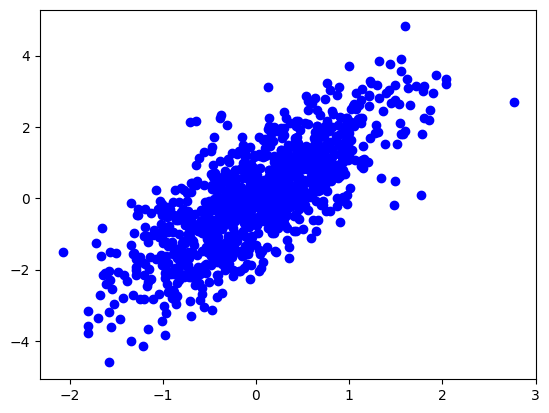

In [18]:
data_path = root_dir / 'data' / 'synthetic_market_1000X5_19.npy'
R = np.load(data_path)

asset_x = R[:, 0]
asset_y = R[:, 1]

plt.scatter(asset_x, asset_y, c='blue')

## Mean centering visualization

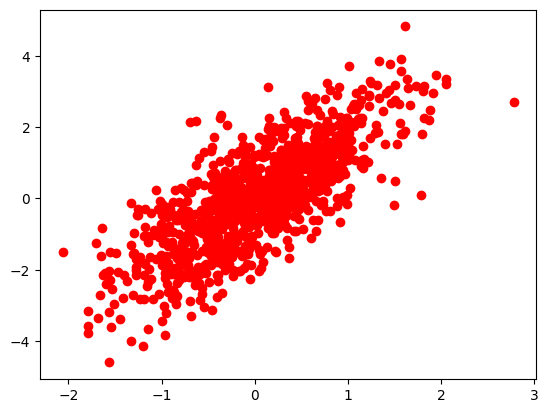

In [17]:
mean_centered = mean_centering(R)

asset_xc = mean_centered[:, 0]
asset_yc = mean_centered[:, 1]

plt.scatter(asset_xc, asset_yc, c='red')

## Covariance Heatmap

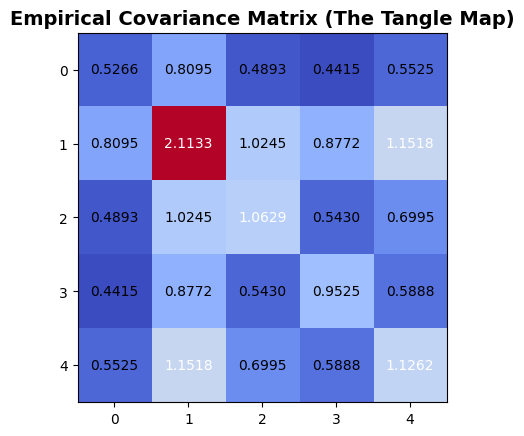

In [21]:
Sigma = empirical_cov_matrix(R)

num_assets = np.shape(Sigma)[0]

plt.imshow(Sigma, cmap='coolwarm', interpolation='nearest')
plt.title("Empirical Covariance Matrix (The Tangle Map)", fontsize=14, fontweight='bold')

for i in range(num_assets):
    for j in range(num_assets):
        plt.text(j, i, f"{Sigma[i, j]:.4f}", ha="center", va="center", 
                color="black" if np.abs(Sigma[i,j]) < np.max(Sigma)*0.5 else "white")

## Plot Eigenvectors

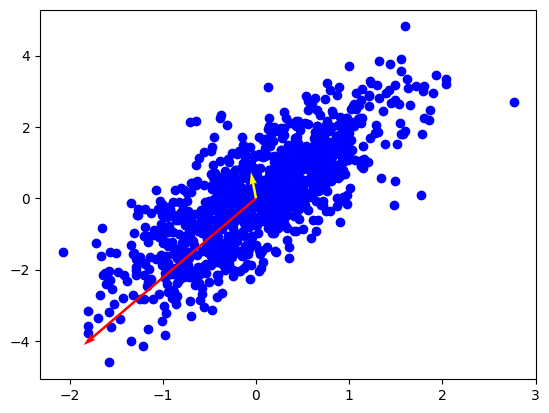

In [28]:
eigenvals, eigenvecs = extract_eigen(Sigma)

scale_factor = 3.0
w1_2d = eigenvecs[:2, 0] * np.sqrt(eigenvals[0]) * scale_factor
w2_2d = eigenvecs[:2, 1] * np.sqrt(eigenvals[1]) * scale_factor

plt.scatter(asset_x, asset_y, c='blue')

plt.quiver(0, 0, w1_2d[0], w1_2d[1], angles='xy', scale_units='xy', scale=1, 
          color='red', width=0.005, label='w1: The Macro Tide')
plt.quiver(0, 0, w2_2d[0], w2_2d[1], angles='xy', scale_units='xy', scale=1, 
          color='yellow', width=0.005, label='w2: Micro Spread')